# Multi-subject EEG Motor Imagery Experiment

This notebook extends the previous subject-specific EEG motor imagery decoding pipeline to multiple subjects.

The goal is to test whether the CSP-based classification pipeline works beyond a single participant.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.decoding import CSP

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [3]:
SUBJECTS = [1, 2, 3, 4, 5]

# Use the same runs as in the previous experiment
RUNS = [6, 10, 14]

FREQ_LOW = 8
FREQ_HIGH = 30

TMIN = 0.5
TMAX = 2.5

N_SPLITS = 5
N_REPEATS = 10
RANDOM_STATE = 42

In [4]:
def load_subject_epochs(subject, runs):
    file_paths = eegbci.load_data(subject, runs)
    
    raws = []
    for file_path in file_paths:
        raw = read_raw_edf(file_path, preload=True, verbose=False)
        eegbci.standardize(raw)
        raws.append(raw)
    
    raw = concatenate_raws(raws)
    
    raw.pick_types(
        eeg=True,
        meg=False,
        stim=False,
        eog=False
    )
    
    raw.set_montage("standard_1005", on_missing="ignore")
    
    raw.filter(
        FREQ_LOW,
        FREQ_HIGH,
        fir_design="firwin",
        verbose=False
    )
    
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    
    selected_event_id = {
        "T1": event_id["T1"],
        "T2": event_id["T2"]
    }
    
    epochs = mne.Epochs(
        raw,
        events,
        event_id=selected_event_id,
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False
    )
    
    X = epochs.get_data()
    y = epochs.events[:, -1]
    
    y = np.where(y == selected_event_id["T1"], 0, 1)
    
    return X, y

In [5]:
models = {
    "CSP + LDA": LinearDiscriminantAnalysis(),
    "CSP + SVM": SVC(kernel="linear"),
    "CSP + Logistic Regression": LogisticRegression(max_iter=1000)
}

In [6]:
results = []
subject_errors = []

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

for subject in SUBJECTS:
    print(f"Processing subject {subject}...")
    
    try:
        X, y = load_subject_epochs(subject, RUNS)
        
        for model_name, classifier in models.items():
            csp = CSP(
                n_components=4,
                reg=None,
                log=True,
                norm_trace=False
            )
            
            pipeline = Pipeline([
                ("CSP", csp),
                ("classifier", classifier)
            ])
            
            scores = cross_val_score(
                pipeline,
                X,
                y,
                cv=cv,
                scoring="accuracy",
                n_jobs=-1
            )
            
            results.append({
                "subject": subject,
                "model": model_name,
                "mean_accuracy": scores.mean(),
                "std_accuracy": scores.std(),
                "n_trials": len(y)
            })
            
    except Exception as e:
        print(f"Subject {subject} failed: {e}")
        subject_errors.append({
            "subject": subject,
            "error": str(e)
        })

Processing subject 1...
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
Computing ran

Download complete in 01m08s (7.3 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 9.2e-05 (2.2e-16 eps * 64 dim * 6.5e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 9.1e-05 (2.2e-16 eps * 64 dim * 6.4e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 9.1e-05 (2.2e-16 eps * 64 dim * 6.4e+09  max singular value)
Reducing data rank from 64 -> 64
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Estimating class=0 covariance using EMP

Download complete in 01m06s (7.4 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.00019 (2.2e-1

Download complete in 01m17s (7.3 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 7.3e-05 (2.2e-16 eps * 64 dim * 5.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 7.5e-05 (2.2e-16 eps * 64 dim * 5.3e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
    Using tolerance 7.3e-05 (2.2e-16 eps * 64 dim * 5.1e+09  max singular value)
Estimating class=0 covariance using EMPIRICAL
Done.
    Estimated rank (data): 64
    data: rank

Download complete in 01m09s (7.3 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 8.2e-05 (2.2e-16 eps * 64 dim * 5.8e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
    Using tolerance 8.4e-05 (2.2e-16 eps * 64 dim * 5.9e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 8.1e-05 (2.2e-16 eps * 64 dim * 5.7e+09  max singular

In [7]:
results_df = pd.DataFrame(results)

results_df

,subject,model,mean_accuracy,std_accuracy,n_trials
0,1,CSP + LDA,0.971111,0.057991,45
1,1,CSP + SVM,0.968889,0.058962,45
2,1,CSP + Logistic Regression,0.968889,0.058962,45
3,2,CSP + LDA,0.837778,0.199022,45
4,2,CSP + SVM,0.835556,0.200296,45
5,2,CSP + Logistic Regression,0.844444,0.183249,45
6,3,CSP + LDA,0.531111,0.157590,45
7,3,CSP + SVM,0.533333,0.106574,45
8,3,CSP + Logistic Regression,0.522222,0.124226,45
9,4,CSP + LDA,0.853333,0.139558,45


In [8]:
results_df.to_csv(
    "../outputs/multi_subject_model_comparison.csv",
    index=False
)

In [9]:
summary_df = (
    results_df
    .groupby("model")
    .agg(
        mean_accuracy_across_subjects=("mean_accuracy", "mean"),
        std_accuracy_across_subjects=("mean_accuracy", "std"),
        mean_cv_std=("std_accuracy", "mean")
    )
    .reset_index()
)

summary_df

,model,mean_accuracy_across_subjects,std_accuracy_across_subjects,mean_cv_std
0,CSP + LDA,0.737778,0.211648,0.140048
1,CSP + Logistic Regression,0.741333,0.220228,0.128717
2,CSP + SVM,0.745333,0.217446,0.129564


In [10]:
summary_df.to_csv(
    "../outputs/multi_subject_summary.csv",
    index=False
)

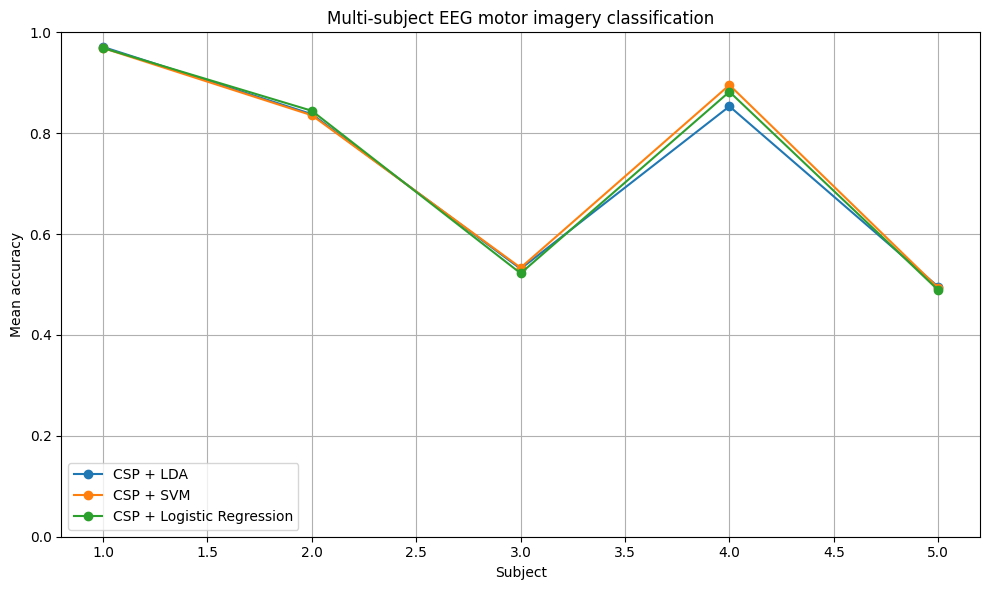

In [11]:
plt.figure(figsize=(10, 6))

for model_name in results_df["model"].unique():
    subset = results_df[results_df["model"] == model_name]
    
    plt.plot(
        subset["subject"],
        subset["mean_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Subject")
plt.ylabel("Mean accuracy")
plt.title("Multi-subject EEG motor imagery classification")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/multi_subject_accuracy_by_subject.png",
    dpi=300
)

plt.show()


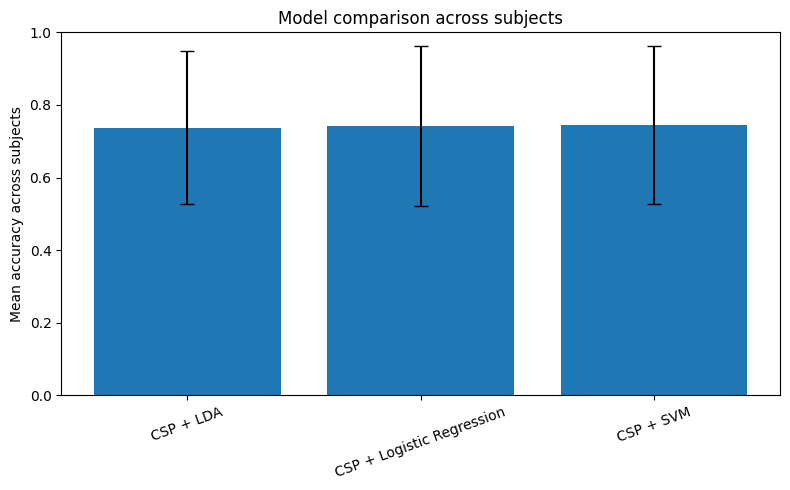

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["model"],
    summary_df["mean_accuracy_across_subjects"],
    yerr=summary_df["std_accuracy_across_subjects"],
    capsize=5
)

plt.ylabel("Mean accuracy across subjects")
plt.title("Model comparison across subjects")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../outputs/multi_subject_model_summary.png",
    dpi=300
)

plt.show()
